<a href="https://colab.research.google.com/github/Wafik20/SOTA-deep-learning-code-samples/blob/main/Generating_MNIST_Using_Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
k = 15.0  # try 15, 20

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# -----------------------------
# Data
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 2*x - 1)
])

train_ds = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)

# -----------------------------
# Forward process (continuous)
# -----------------------------
def alpha(t):
    return torch.exp(-k * t)

def forward_diffusion(x0, t):
    eps = torch.randn_like(x0)
    a = alpha(t).view(-1,1,1,1)
    xt = torch.sqrt(a) * x0 + torch.sqrt(1 - a) * eps
    return xt, eps

# -----------------------------
# Time embedding + model
# -----------------------------
def time_embed(t, dim=32):
    half = dim // 2
    assert half > 1
    freqs = torch.exp(
        -np.log(10000) * torch.arange(half, device=t.device).float() / (half - 1)
    )
    args = t[:, None] * freqs[None, :] * 2 * np.pi
    return torch.cat([torch.sin(args), torch.cos(args)], dim=1)

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.10MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.66MB/s]


In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

def sinusoidal_time_embed(t, dim=128):
    """
    t: (B,) in [0,1]
    returns: (B, dim)
    """
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, device=t.device).float() / (half - 1)
    )
    args = t[:, None] * freqs[None, :] * 2 * math.pi
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, cdim, groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.c_proj = nn.Linear(cdim, out_ch)   # <- was t_proj

        self.skip = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, 1)

    def forward(self, x, cemb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.c_proj(cemb)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

class BetterUNet(nn.Module):
    def __init__(self, in_ch=1, base=64, tdim=128, num_classes=10):
        super().__init__()
        self.tdim = tdim
        self.num_classes = num_classes

        # time MLP
        self.t_mlp = nn.Sequential(
            nn.Linear(tdim, 4*tdim),
            nn.SiLU(),
            nn.Linear(4*tdim, tdim),
        )

        # label embedding (+1 for "null" label used by CFG)
        self.y_emb = nn.Embedding(num_classes + 1, tdim)  # last index = null

        self.in_conv = nn.Conv2d(in_ch, base, 3, padding=1)

        # now blocks take cdim=tdim
        self.rb1 = ResBlock(base, base, tdim)
        self.rb2 = ResBlock(base, base, tdim)
        self.down1 = Downsample(base)

        self.rb3 = ResBlock(base, 2*base, tdim)
        self.rb4 = ResBlock(2*base, 2*base, tdim)
        self.down2 = Downsample(2*base)

        self.mid1 = ResBlock(2*base, 2*base, tdim)
        self.mid2 = ResBlock(2*base, 2*base, tdim)

        self.up1 = Upsample(2*base)
        self.rb5 = ResBlock(4*base, 2*base, tdim)
        self.rb6 = ResBlock(2*base, base, tdim)

        self.up2 = Upsample(base)
        self.rb7 = ResBlock(2*base, base, tdim)
        self.rb8 = ResBlock(base, base, tdim)

        self.out_norm = nn.GroupNorm(8, base)
        self.out_conv = nn.Conv2d(base, 1, 3, padding=1)

    def forward(self, x, t, y=None):
        """
        y: (B,) int64 in [0..9] or None.
        If y is None, we use the "null" class (for unconditional).
        """
        B = x.size(0)
        temb = self.t_mlp(sinusoidal_time_embed(t, self.tdim))

        if y is None:
            y = torch.full((B,), self.num_classes, device=x.device, dtype=torch.long)  # null
        yemb = self.y_emb(y)

        cemb = temb + yemb  # simplest fusion

        x = self.in_conv(x)

        h1 = self.rb2(self.rb1(x, cemb), cemb)
        d1 = self.down1(h1)

        h2 = self.rb4(self.rb3(d1, cemb), cemb)
        d2 = self.down2(h2)

        m = self.mid2(self.mid1(d2, cemb), cemb)

        u1 = self.up1(m)
        u1 = torch.cat([u1, h2], dim=1)
        u1 = self.rb6(self.rb5(u1, cemb), cemb)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, h1], dim=1)
        u2 = self.rb8(self.rb7(u2, cemb), cemb)

        return self.out_conv(F.silu(self.out_norm(u2)))

In [ ]:
def make_ema(model, decay=0.999):
    ema = BetterUNet(base=64, tdim=128, num_classes=10).to(next(model.parameters()).device)
    ema.load_state_dict(model.state_dict())
    for p in ema.parameters():
        p.requires_grad_(False)
    return ema, decay

@torch.no_grad()
def ema_update(ema, model, decay):
    msd = model.state_dict()
    for k, v in ema.state_dict().items():
        v.copy_(decay * v + (1.0 - decay) * msd[k])

In [ ]:
model = BetterUNet(base=64, tdim=128).to(device)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

ema, ema_decay = make_ema(model, decay=0.999)

num_epochs = 20
T = 1000
ts_grid = torch.linspace(0.0, 1.0, T+1, device=device)
abar_grid = torch.exp(-k * ts_grid).clamp(1e-8, 1.0)
p_uncond = 0.1  # 10% unconditional during training

def forward_diffusion_discrete(x0, i):
    eps = torch.randn_like(x0)
    ab = abar_grid[i].view(-1,1,1,1)
    xt = torch.sqrt(ab) * x0 + torch.sqrt(1.0 - ab) * eps
    return xt, eps

for epoch in range(num_epochs):
    model.train()
    running = 0.0
    for x0, y in train_loader:
        x0 = x0.to(device)
        y  = y.to(device)
        B = x0.size(0)

        # sample diffusion step
        i = torch.randint(1, T+1, (B,), device=device)
        t = i.float() / T

        xt, eps = forward_diffusion_discrete(x0, i)

        # CFG label dropout
        drop = (torch.rand(B, device=device) < p_uncond)
        y_cond = y.clone()
        y_cond[drop] = 10   # null index (num_classes)

        eps_pred = model(xt, t, y_cond)

        loss = (eps_pred - eps).pow(2).mean()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema_update(ema, model, ema_decay)

        running += loss.item()

    print(f"epoch {epoch:03d} | loss {running/len(train_loader):.4f}")


epoch 000 | loss 0.0277
epoch 001 | loss 0.0087
epoch 002 | loss 0.0075
epoch 003 | loss 0.0070
epoch 004 | loss 0.0067
epoch 005 | loss 0.0063
epoch 006 | loss 0.0061
epoch 007 | loss 0.0061
epoch 008 | loss 0.0061
epoch 009 | loss 0.0060
epoch 010 | loss 0.0059
epoch 011 | loss 0.0059
epoch 012 | loss 0.0058
epoch 013 | loss 0.0057
epoch 014 | loss 0.0058
epoch 015 | loss 0.0057
epoch 016 | loss 0.0057
epoch 017 | loss 0.0056
epoch 018 | loss 0.0056
epoch 019 | loss 0.0056


In [ ]:
# -----------------------------
# Small-t MSE diagnostic
# -----------------------------
x0, _ = next(iter(train_loader))
x0 = x0.to(device)
t_small = torch.full((x0.size(0),), 0.02, device=device)
xt, eps = forward_diffusion(x0, t_small)          # continuous forward ok for eval
eps_pred = model(xt, t_small)
print("small-t mse:", ((eps - eps_pred)**2).mean().item())

small-t mse: 0.04357052594423294


In [ ]:
def cfg_forward(ema, x, t, y, guidance):
    # duplicate batch
    x2 = torch.cat([x, x], dim=0)
    t2 = torch.cat([t, t], dim=0)

    y_null = torch.full_like(y, 10)
    y2 = torch.cat([y, y_null], dim=0)

    eps = ema(x2, t2, y2)
    eps_cond, eps_uncond = eps.chunk(2, dim=0)

    return eps_uncond + guidance * (eps_cond - eps_uncond)

In [ ]:
@torch.no_grad()
def ddim_sample_cond(
    n=16,
    digit=3,
    guidance=3.0,
    steps=50,
    eta=0.0,   # 0 = deterministic (fastest)
):
    ema.eval()
    device = abar_grid.device

    x = torch.randn(n, 1, 28, 28, device=device)
    y = torch.full((n,), digit, device=device, dtype=torch.long)

    # pick timesteps (uniform or quadratic)
    times = torch.linspace(1.0, 0.0, steps + 1, device=device)
    idxs = (times * T).long().clamp(1, T)

    for j in range(steps):
        i = idxs[j]
        i_prev = idxs[j + 1]

        t = torch.full((n,), i / T, device=device)

        eps_c = ema(x, t, y)
        eps_u = ema(x, t, None)

        eps = cfg_forward(ema, x, t, y, guidance)

        ab_t = abar_grid[i]
        ab_prev = abar_grid[i_prev]

        # predict x0
        x0 = (x - torch.sqrt(1 - ab_t) * eps) / torch.sqrt(ab_t)

        # DDIM update
        x = (
            torch.sqrt(ab_prev) * x0
            + torch.sqrt(1 - ab_prev) * eps
        )

    return x

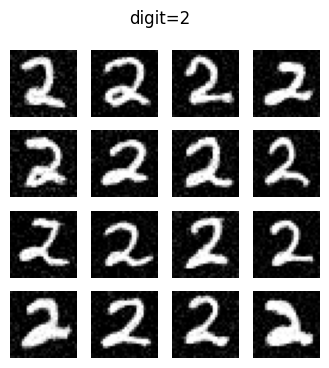

In [ ]:
digit = 2
samples = ddim_sample_cond(16, digit=digit, guidance=3.0).cpu().clamp(-1, 1)
samples = (samples + 1) / 2

fig, axs = plt.subplots(4,4, figsize=(4,4))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(samples[i,0], cmap="gray")
    ax.axis("off")
plt.suptitle(f"digit={digit}")
plt.show()

In [ ]:
def sample_digit_batch(digit, n=16, guidance=3.0):
    samples = ddim_sample_cond(
        n,
        digit=digit,
        guidance=guidance
    )
    return samples.clamp(-1, 1)

In [ ]:
def number_to_digits(num):
    return [int(d) for d in str(num)]

In [ ]:
def sample_number(
    num,
    n=16,
    guidance=3.0,
    gap=2  # pixels between digits
):
    digits = number_to_digits(num)
    digit_imgs = []

    for d in digits:
        imgs = sample_digit_batch(d, n=n, guidance=guidance)
        digit_imgs.append(imgs)

    # imgs: list of (n, 1, 28, 28)
    # concatenate width-wise
    out = digit_imgs[0]
    for imgs in digit_imgs[1:]:
        pad = torch.zeros(
            n, 1, 28, gap, device=imgs.device
        )
        out = torch.cat([out, pad, imgs], dim=3)

    return out

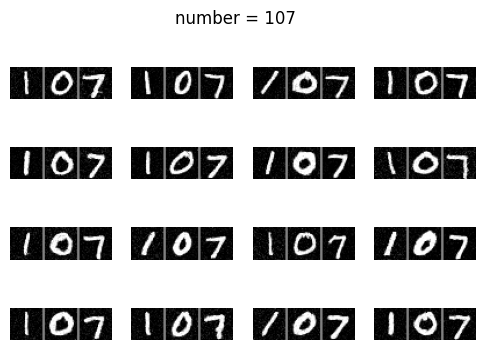

In [ ]:
num = 107
samples = sample_number(num, n=16, guidance=3.0)
samples = samples.detach().cpu()
samples = (samples + 1) / 2

fig, axs = plt.subplots(4, 4, figsize=(6, 4))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(samples[i, 0], cmap="gray")
    ax.axis("off")
plt.suptitle(f"number = {num}")
plt.show()